# 06. Working with Data Structures
## Lists and Dictionaries

## 📚 Learning Objectives

By completing this notebook, you will:
- Work with lists: indexing, slicing, and transformations
- Work with dictionaries: key-value pairs and operations
- Transform data between structures
- Apply data manipulation techniques
- Use common operations for data science

## 🔗 Where this fits

**Builds on:** Course 01 (AIAT 111) — Unit 2, lesson 01 "Applied Review of Python Basics" — the same structures, now as the layer beneath a DataFrame.

**Used later in:** Course 05 — Unit 2, lesson 01, where nested JSON has to be flattened into rows and columns.

---

This notebook covers practical activities from **Course 05, Unit 1**:
- Working with Data Structures: Performing tasks like indexing, slicing, and transforming data using lists and dictionaries

---

## The Story: Organizing Your Tools

Imagine you're organizing a toolbox. **Before** you can work efficiently, you need to know how to organize tools - some go in drawers (lists), some have labels (dictionaries). **After** organizing properly, you can find any tool instantly!

Same with data: **Before** analyzing data, we learn data structures - lists for sequences, dictionaries for labeled data. **After** mastering structures, we can organize any data efficiently!

---

## Why Data Structures Matter

Data structures are essential because:
- **Lists**: Store sequences of data (like rows in a table)
- **Dictionaries**: Store labeled data (like columns with names)
- **Together**: They form the foundation for pandas DataFrames
- **In data science**: All data manipulation uses these structures

**Common Student Questions:**
- **Q: When do I use a list vs dictionary?**
  - Answer: Lists for ordered sequences, dictionaries for labeled data
  - Example: List = [1, 2, 3] (just values), Dict = {'name': 'John', 'age': 25} (labeled)
  - In data science: Lists for rows, dictionaries for records with fields
  
- **Q: What is indexing and slicing?**
  - Answer: Indexing = get one item, Slicing = get multiple items
  - Example: `list[0]` = first item, `list[0:3]` = first three items
  - In data science: Extract specific rows or columns from data

---

## Introduction

**Lists and dictionaries** are fundamental Python data structures for storing and manipulating data. Mastering these structures is essential for data science workflows, as pandas DataFrames are built on these concepts.


## 🎯 The case: six minutes of loading, and one missing hash table

*Grand Theft Auto Online* took about **six minutes** to load on a fast PC, and had done so
for years. In February 2021 a player writing as **t0st** profiled the running game and
published the cause: at startup it parses a **10 MB JSON** catalogue of about 63,000 items,
and does it twice badly. First, it parses with `sscanf`, which measures the length of the
entire remaining string on every single item — turning a linear job into a quadratic one.
Second, before storing each item it scans the *whole* array already built to check for
duplicates — roughly **1.98 billion** comparisons for a list that contains no duplicates
at all. t0st patched both in an injected DLL and cut loading from about six minutes to
about two — a **70%** reduction. Rockstar confirmed the finding, shipped an official fix,
and paid t0st a $10,000 bug bounty.

The second bug is the one that belongs in this lesson. "Have I seen this item before?" is a
**list** question when you ask it with `in`, and Python must walk every element. Make the
container a **set** or a **dict** and the same question is answered by a hash lookup that
does not care how big the collection is. Same data, same answer, different structure —
and, at scale, four minutes of a player's life per session.

**What goes wrong without this.** Below you count survivors with a plain dictionary
(`survivors[pclass] += 1`). Write that same count with a list and an `in` check on 891
passengers and nobody notices. Write it on the 663,522-row Montgomery 911 log from lesson
01 and you have just built GTA Online's loading screen.


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Lists, dicts, list↔dict conversions, nested structures — taught on short
  literal examples, because the lesson is Python syntax
- **Real data:** `titanic.csv` — every "real-world example" below reads actual
  passenger records from the RMS Titanic manifest, using nothing but the standard
  library's `csv` module. That is the shape data arrives in before pandas.

**Outputs:** What you'll see when you run the cells

- Each structure demonstrated, then applied to real passenger records
- A list of dicts assembled by hand — exactly what `pd.DataFrame()` ingests

---


In [1]:
# ============================================================================
# ============================================================================
print("=" * 70)
print("=" * 70)

print("\n📋 PART 1: Lists")
print("-" * 70)

# Example 1: Creating and accessing lists
print("\n✅ Example 1: Creating and Accessing Lists")
print("-" * 70)

# Create a list
fruits = ["apple", "banana", "orange", "grape", "mango"]
print(f"   List: {fruits}")

# Indexing: Access single element
print(f"   First fruit (index 0): {fruits[0]}")
print(f"   Last fruit (index -1): {fruits[-1]}")

# Slicing: Access multiple elements
print(f"   First 3 fruits (slice [0:3]): {fruits[0:3]}")
print(f"   Last 2 fruits (slice [-2:]): {fruits[-2:]}")

# Example 2: List methods
print("\n✅ Example 2: List Methods")
print("-" * 70)


📋 PART 1: Lists
----------------------------------------------------------------------

✅ Example 1: Creating and Accessing Lists
----------------------------------------------------------------------
   List: ['apple', 'banana', 'orange', 'grape', 'mango']
   First fruit (index 0): apple
   Last fruit (index -1): mango
   First 3 fruits (slice [0:3]): ['apple', 'banana', 'orange']
   Last 2 fruits (slice [-2:]): ['grape', 'mango']

✅ Example 2: List Methods
----------------------------------------------------------------------


In [2]:
# WHAT: Practice core list operations - append, insert, remove, comprehensions - then apply them to REAL ticket fares.
# WHY: Lists are Python's workhorse sequence; comprehensions turn multi-line loops into readable one-liners.

numbers = [1, 2, 3]
print(f"   Original: {numbers}")

# Add elements
numbers.append(4)  # Add to end
print(f"   After append(4): {numbers}")

numbers.insert(1, 10)  # Insert at position 1
print(f"   After insert(1, 10): {numbers}")

# Remove elements
numbers.remove(10)  # Remove value 10
print(f"   After remove(10): {numbers}")

# List comprehensions (powerful feature!)
squared = [x ** 2 for x in range(1, 6)]
print(f"   Squared numbers [1-5]: {squared}")

# Real-world example: real data, read with the standard library only
print("\n📊 Real-world example: ticket fares from the Titanic manifest")
import csv

# --- Data setup. Works from any folder, and on Google Colab. -------------------------
# WHAT: find the repository root and put it on sys.path, then import the shared loader.
# WHY:  a hard-coded '../../../Course 04/datasets/raw/titanic.csv' only resolves when the
#       kernel's working directory happens to be this notebook's folder. This does not care.
import sys, pathlib

_here = pathlib.Path.cwd().resolve()
_root = next((p for p in [_here, *_here.parents] if (p / "tools" / "data.py").exists()), None)
if _root is None:                     # Google Colab, or a stray copy of the notebook
    import urllib.request
    pathlib.Path("tools").mkdir(exist_ok=True)
    try:
        urllib.request.urlretrieve("https://raw.githubusercontent.com/A-Alwabel/AI-Diploma-Program/main/tools/data.py", "tools/data.py")
    except Exception as _e:
        raise RuntimeError(
            "Could not find the AI Diploma repository from this folder, and could not "
            "download the data loader either. Open this notebook inside a clone of "
            "https://github.com/A-Alwabel/AI-Diploma-Program, or connect to the internet "
            f"and re-run this cell. (underlying error: {_e})") from None
    _root = pathlib.Path.cwd()
sys.path.insert(0, str(_root))

from tools.data import load, path as dataset_path
# -------------------------------------------------------------------------------------
with open(dataset_path("titanic"), newline='', encoding='utf-8') as f:
    passengers = list(csv.DictReader(f))

print(f"   Rows read: {len(passengers)} real passengers")

# A list comprehension pulls one column out of the records
fares = [float(p['Fare']) for p in passengers]
print(f"   First 5 fares: {[round(x, 2) for x in fares[:5]]}")
print(f"   Highest: £{max(fares):.2f}")
print(f"   Lowest:  £{min(fares):.2f}")
print(f"   Average: £{sum(fares) / len(fares):.2f}")
n_zero = sum(1 for x in fares if x == 0.0)
print(f"   ({n_zero} passengers have a recorded fare of exactly £0.00. That is a value in")
print("    the file, not a missing one - always ask what a zero MEANS before averaging it.)")

# ============================================================================
# PART 2: DICTIONARIES
# ============================================================================
print("\n" + "=" * 70)

   Original: [1, 2, 3]
   After append(4): [1, 2, 3, 4]
   After insert(1, 10): [1, 10, 2, 3, 4]
   After remove(10): [1, 2, 3, 4]
   Squared numbers [1-5]: [1, 4, 9, 16, 25]

📊 Real-world example: ticket fares from the Titanic manifest
titanic: full file, 891 rows.
   Rows read: 891 real passengers
   First 5 fares: [7.25, 71.28, 7.92, 53.1, 8.05]
   Highest: £512.33
   Lowest:  £0.00
   Average: £32.20
   (15 passengers have a recorded fare of exactly £0.00. That is a value in
    the file, not a missing one - always ask what a zero MEANS before averaging it.)



Reading real 911 call descriptions (standard-library csv, first 24,000 rows)...
montgomery_911_calls: bundled 25,000-row sample of the 663,522-row original (the full file is on this machine but was not used, because prefer='sample') — every number below is for the sample, not the full file. How it was drawn: 1 row in every 27, evenly spread, so the sample covers the same 2015-12-10 to 2020-07-29 window with all 100 call types and 68 townships.
   24,000 real descriptions read in 0.03s
   Distinct among them: 24,000

  records    list (s)     set (s)   list / set
----------------------------------------------
    1,500      0.0050      0.0001          47x
    3,000      0.0207      0.0002          91x
    6,000      0.0810      0.0004         191x


   12,000      0.3300      0.0008         392x


   24,000      1.3534      0.0017         813x


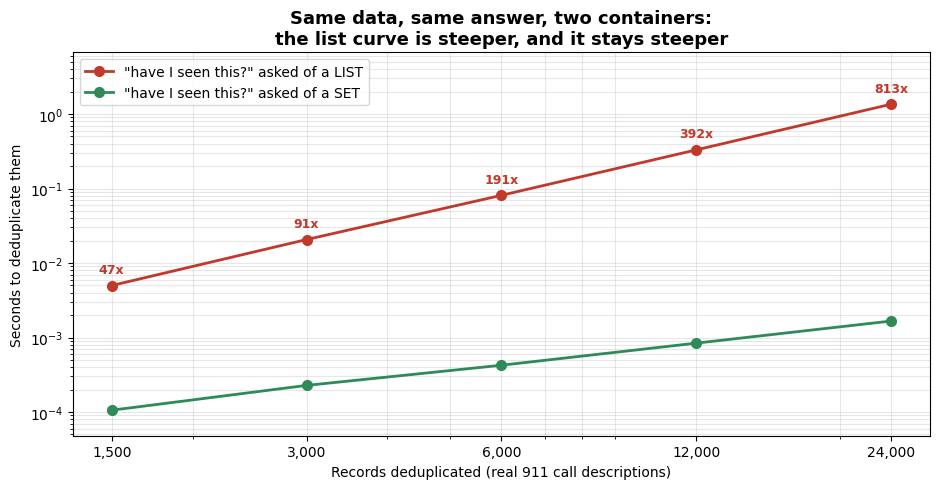


Doubling the input from 12,000 to 24,000 records multiplied the
   LIST version by 4.1x  (doubling work would be 2.0x, quadrupling 4.0x)
   SET  version by 2.0x

GTA Online did this to a 63,000-item catalogue on every single launch.


In [3]:
# WHAT: Reproduce the GTA Online bug on real data - deduplicate the same call descriptions
#       twice, once asking "have I seen this?" of a LIST and once of a SET - and time both.
# WHY: The lesson claims a list membership test is a linear scan and a set membership test is
#      not. That is a claim about how the cost GROWS, so it can only be shown by growing the
#      input and plotting the result.

import time
import itertools
import matplotlib.pyplot as plt

# Real material: the free-text description of each 911 call in the Montgomery County log.
# Why 'desc'? It is close to unique per call, which is the honest worst case for the list -
# exactly like GTA's 63,000-item catalogue with no duplicates in it at all.
print("Reading real 911 call descriptions (standard-library csv, first 24,000 rows)...")
t0 = time.time()
with open(dataset_path("montgomery_911_calls", prefer="sample"),
          newline='', encoding='utf-8') as f:
    descriptions = [row['desc'] for row in itertools.islice(csv.DictReader(f), 24_000)]
print(f"   {len(descriptions):,} real descriptions read in {time.time() - t0:.2f}s")
print(f"   Distinct among them: {len(set(descriptions)):,}\n")

sizes = [1_500, 3_000, 6_000, 12_000, 24_000]
list_times, set_times = [], []

print(f"{'records':>9}  {'list (s)':>10}  {'set (s)':>10}  {'list / set':>11}")
print("-" * 46)
for n in sizes:
    batch = descriptions[:n]

    # THE BUG: `in` on a list walks every element already stored. Quadratic overall.
    t0 = time.time()
    seen_list = []
    for item in batch:
        if item not in seen_list:
            seen_list.append(item)
    t_list = time.time() - t0

    # THE FIX: `in` on a set is a hash lookup. It does not care how much is already stored.
    t0 = time.time()
    seen_set, kept = set(), []
    for item in batch:
        if item not in seen_set:
            seen_set.add(item)
            kept.append(item)
    t_set = time.time() - t0

    assert len(seen_list) == len(kept)     # both routes must find the same unique items
    list_times.append(t_list)
    set_times.append(t_set)
    print(f"{n:>9,}  {t_list:>10.4f}  {t_set:>10.4f}  {t_list / t_set:>10,.0f}x")

fig, ax = plt.subplots(figsize=(9.5, 5.0))
ax.plot(sizes, list_times, 'o-', color='#C0392B', linewidth=2, markersize=7,
        label='"have I seen this?" asked of a LIST')
ax.plot(sizes, set_times, 'o-', color='#2E8B57', linewidth=2, markersize=7,
        label='"have I seen this?" asked of a SET')

# Why log-log? On these axes a straight line IS the growth rate: slope 1 = linear,
# slope 2 = quadratic. The shapes of the two lines are the entire lesson.
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Records deduplicated (real 911 call descriptions)')
ax.set_ylabel('Seconds to deduplicate them')
ax.set_title('Same data, same answer, two containers:\nthe list curve is steeper, and it stays steeper',
             fontsize=13, weight='bold')
ax.set_ylim(min(set_times) / 2.2, max(list_times) * 5)   # headroom for the ratio labels
ax.grid(True, which='both', alpha=0.3)
ax.legend(loc='upper left', fontsize=10)

# Tick the x-axis at the sizes we actually measured - a log axis whose only label is
# "10^4" tells the reader nothing about what was run.
import matplotlib.ticker as mticker
ax.set_xticks(sizes)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
ax.xaxis.set_minor_formatter(mticker.NullFormatter())

# Label the ratio at each measured point so the growing gap is a number, not an impression.
for n, tl, ts in zip(sizes, list_times, set_times):
    ax.annotate(f'{tl / ts:,.0f}x', xy=(n, tl), xytext=(0, 9),
                textcoords='offset points', ha='center', fontsize=9,
                weight='bold', color='#C0392B')

plt.tight_layout()
plt.show()

growth_list = list_times[-1] / list_times[-2]
growth_set = set_times[-1] / set_times[-2]
print(f"\nDoubling the input from {sizes[-2]:,} to {sizes[-1]:,} records multiplied the")
print(f"   LIST version by {growth_list:.1f}x  (doubling work would be 2.0x, quadrupling 4.0x)")
print(f"   SET  version by {growth_set:.1f}x")
print("\nGTA Online did this to a 63,000-item catalogue on every single launch.")


### 👁️ Read the figure

- **Two lines, same input, same output.** Both loops deduplicated the *same* real 911 call
  descriptions and found the *same* unique items — the cell asserts that before plotting. The
  only difference is whether `in` was asked of a list or of a set.
- **Both axes are logarithmic, and that is what makes the shape readable.** On log-log axes a
  straight line's steepness *is* its growth rate: the green set line rises roughly one unit
  for one unit (linear — double the data, double the time), while the red list line rises
  about twice as fast (quadratic — double the data, **quadruple** the time).
- **The red number above each point is the ratio at that size.** It is not a constant. It
  grows with every step along the x-axis, because the two lines are diverging, not merely
  offset. Read the printed table underneath for the exact seconds.

**What it proves:** "use a set for membership" is not a micro-optimisation, because the
penalty is not a fixed multiplier — it scales with your data. At a few thousand records the
list version is merely wasteful; carry the same code to the 663,522-row 911 log from lesson 01
and it stops finishing. That is precisely the second GTA Online bug: same catalogue, same
result, wrong container, four minutes of a player's life per launch.


In [4]:
# WHAT: Create a dictionary, access values by key (including safe .get), and list its keys/values/items.
# WHY: Dictionaries model labeled records - the same key-value idea behind DataFrame rows and JSON data.

print("PART 2: Dictionaries")
print("=" * 70)

# Example 1: Creating and accessing dictionaries
print("\n✅ Example 1: Creating and Accessing Dictionaries")
print("-" * 70)

# Create a dictionary (key-value pairs)
student = {
    "name": "Ahmed",
    "age": 20,
    "grade": "A",
    "courses": ["Math", "Python", "Data Science"]
}
print(f"   Student dictionary: {student}")

# Access by key
print(f"   Name: {student['name']}")
print(f"   Age: {student['age']}")

# Safe access with .get() (returns None if key doesn't exist)
print(f"   Email: {student.get('email', 'Not provided')}")

# Example 2: Dictionary methods
print("\n✅ Example 2: Dictionary Methods")
print("-" * 70)

print(f"   Keys: {list(student.keys())}")
print(f"   Values: {list(student.values())}")
print(f"   Items: {list(student.items())}")

PART 2: Dictionaries

✅ Example 1: Creating and Accessing Dictionaries
----------------------------------------------------------------------
   Student dictionary: {'name': 'Ahmed', 'age': 20, 'grade': 'A', 'courses': ['Math', 'Python', 'Data Science']}
   Name: Ahmed
   Age: 20
   Email: Not provided

✅ Example 2: Dictionary Methods
----------------------------------------------------------------------
   Keys: ['name', 'age', 'grade', 'courses']
   Values: ['Ahmed', 20, 'A', ['Math', 'Python', 'Data Science']]
   Items: [('name', 'Ahmed'), ('age', 20), ('grade', 'A'), ('courses', ['Math', 'Python', 'Data Science'])]


In [5]:
# WHAT: Update a dictionary, then hold many REAL records as a list of dicts.
# WHY: A list of dicts is how records arrive from a CSV reader, a JSON API or a database cursor.

# Add/update values
student["email"] = "ahmed@example.com"
print(f"   After adding email: {student['email']}")

# Real-world example: many records, each one a dictionary
print("\n📊 Real-world example: real passenger records")
sample_records = [
    {'name': p['Name'], 'class': int(p['Pclass']), 'fare': float(p['Fare'])}
    for p in passengers[:5]
]

print("   Passenger records:")
for record in sample_records:
    print(f"   - {record['name'][:38]:38s} class {record['class']}  £{record['fare']:.2f}")

# Real data has gaps. Age is blank for 177 of these 891 passengers, and .get()
# with a default is how you survive a key that may be missing or empty.
missing_age = sum(1 for p in passengers if not p['Age'])
print(f"\n   Passengers with no recorded age: {missing_age} of {len(passengers)}")
print(f"   Safe access on the first passenger: "
      f"age = {passengers[0].get('Age') or 'not recorded'}")

# ============================================================================
# PART 3: TRANSFORMATIONS
# ============================================================================
print("\n" + "=" * 70)
print("PART 3: Transformations")
print("=" * 70)

# Example 1: List to Dictionary
print("\n✅ Example 1: List to Dictionary")
print("-" * 70)

# Convert list of tuples to dictionary
pairs = [("name", "Ahmed"), ("age", 20), ("city", "Riyadh")]
student_dict = dict(pairs)
print(f"   Pairs: {pairs}")

   After adding email: ahmed@example.com

📊 Real-world example: real passenger records
   Passenger records:
   - Braund, Mr. Owen Harris                class 3  £7.25
   - Cumings, Mrs. John Bradley (Florence B class 1  £71.28
   - Heikkinen, Miss. Laina                 class 3  £7.92
   - Futrelle, Mrs. Jacques Heath (Lily May class 1  £53.10
   - Allen, Mr. William Henry               class 3  £8.05

   Passengers with no recorded age: 177 of 891
   Safe access on the first passenger: age = 22

PART 3: Transformations

✅ Example 1: List to Dictionary
----------------------------------------------------------------------
   Pairs: [('name', 'Ahmed'), ('age', 20), ('city', 'Riyadh')]


In [6]:
# WHAT: Convert between dictionaries and lists, then filter a list of REAL records.
# WHY: 'List of dicts' is the shape most real-world data arrives in (JSON, APIs, csv.DictReader)
#      and what pandas ingests directly.

print(f"   Dictionary: {student_dict}")

# Example 2: Dictionary to List
print("\n✅ Example 2: Dictionary to List")
print("-" * 70)

data = {"a": 1, "b": 2, "c": 3}
keys_list = list(data.keys())
values_list = list(data.values())
print(f"   Dictionary: {data}")
print(f"   Keys as list: {keys_list}")
print(f"   Values as list: {values_list}")

# Example 3: Nested structures
print("\n✅ Example 3: Nested Structures")
print("-" * 70)

# List of dictionaries built from the real manifest (common in data science!)
manifest = [
    {"name": p['Name'], "sex": p['Sex'], "pclass": int(p['Pclass']),
     "fare": float(p['Fare']), "survived": int(p['Survived'])}
    for p in passengers
]

print("   First three records:")
for person in manifest[:3]:
    print(f"   - {person['name'][:34]:34s} {person['sex']:6s} "
          f"class {person['pclass']}  £{person['fare']:.2f}")

# Filter data with a comprehension - no pandas involved
first_class = [person for person in manifest if person['pclass'] == 1]
print(f"\n   First-class passengers: {len(first_class)} of {len(manifest)}")

   Dictionary: {'name': 'Ahmed', 'age': 20, 'city': 'Riyadh'}

✅ Example 2: Dictionary to List
----------------------------------------------------------------------
   Dictionary: {'a': 1, 'b': 2, 'c': 3}
   Keys as list: ['a', 'b', 'c']
   Values as list: [1, 2, 3]

✅ Example 3: Nested Structures
----------------------------------------------------------------------
   First three records:
   - Braund, Mr. Owen Harris            male   class 3  £7.25
   - Cumings, Mrs. John Bradley (Floren female class 1  £71.28
   - Heikkinen, Miss. Laina             female class 3  £7.92

   First-class passengers: 216 of 891


In [7]:
# WHAT: Summarise the filtered records, then extract parallel columns with comprehensions.
# WHY: Pulling parallel lists out of records is exactly what pandas automates - doing it by hand explains what DataFrames do for you.

# A dictionary used as a counter - the pattern behind groupby()
survivors_by_class = {}
totals_by_class = {}
for person in manifest:
    cls = person['pclass']
    totals_by_class[cls] = totals_by_class.get(cls, 0) + 1
    survivors_by_class[cls] = survivors_by_class.get(cls, 0) + person['survived']

print("   Survival by travel class (counted with a plain dict):")
for cls in sorted(totals_by_class):
    rate = survivors_by_class[cls] / totals_by_class[cls]
    print(f"   - class {cls}: {survivors_by_class[cls]:3d} of "
          f"{totals_by_class[cls]:3d} survived  ({rate:.1%})")

# ============================================================================
# ============================================================================
print("\n" + "=" * 70)
print("PART 4: Data Science Applications")
print("=" * 70)

# Example: Prepare data for pandas
print("\n📊 Example: Prepare Data for a Pandas DataFrame")
print("-" * 70)

# Data as a list of dictionaries - the exact format pd.DataFrame() accepts
records = manifest[:4]

print("   Records (list of dictionaries):")
for record in records:
    print(f"   {record}")

# Extract specific columns
names = [record["name"] for record in records]
fares = [record["fare"] for record in records]
print(f"\n   Names: {[n[:22] for n in names]}")

   Survival by travel class (counted with a plain dict):
   - class 1: 136 of 216 survived  (63.0%)
   - class 2:  87 of 184 survived  (47.3%)
   - class 3: 119 of 491 survived  (24.2%)

PART 4: Data Science Applications

📊 Example: Prepare Data for a Pandas DataFrame
----------------------------------------------------------------------
   Records (list of dictionaries):
   {'name': 'Braund, Mr. Owen Harris', 'sex': 'male', 'pclass': 3, 'fare': 7.25, 'survived': 0}
   {'name': 'Cumings, Mrs. John Bradley (Florence Briggs Thayer)', 'sex': 'female', 'pclass': 1, 'fare': 71.2833, 'survived': 1}
   {'name': 'Heikkinen, Miss. Laina', 'sex': 'female', 'pclass': 3, 'fare': 7.925, 'survived': 1}
   {'name': 'Futrelle, Mrs. Jacques Heath (Lily May Peel)', 'sex': 'female', 'pclass': 1, 'fare': 53.1, 'survived': 1}

   Names: ['Braund, Mr. Owen Harri', 'Cumings, Mrs. John Bra', 'Heikkinen, Miss. Laina', 'Futrelle, Mrs. Jacques']


## 💬 Discuss

A plain dictionary used as a counter just reproduced the survival gap: **class 1: 63.0%,
class 2: 47.3%, class 3: 24.2%** — 136 of 216, 87 of 184, 119 of 491.

1. You could have stored these 891 records as (a) a list of dicts, (b) a dict keyed by
   passenger ID, or (c) parallel lists — one for names, one for fares. Each makes a
   different question cheap. Name the question each one is best at, and say which you would
   choose if the next request from your client is "show me passenger 806".
2. The fares list contains **15 passengers with a recorded fare of exactly £0.00**, and
   the average of £32.20 includes them. Should it? Argue both ways, then state what you
   would need to know about the original ledger to decide — and what you would print in a
   report while you are still unsure.
3. `pd.DataFrame(manifest)` would have produced this table in one line. Given that, make
   the case that building it by hand was worth your time — or make the case that it was
   not. Be specific about what a student who skipped this notebook would fail to
   understand later.


In [8]:
# WHAT: Total the extracted fares and recap the notebook.
# WHY: Ending with a computed number (not a hardcoded one) shows the data structures doing real analysis work.

print(f"   Fares: {[round(f, 2) for f in fares]}")
print(f"   Total fare for these {len(fares)} passengers: £{sum(fares):.2f}")
print(f"   Total fare across all {len(manifest)} passengers: "
      f"£{sum(p['fare'] for p in manifest):,.2f}")
print("\n   💡 Everything above used only lists, dicts and comprehensions.")
print("      `pd.DataFrame(manifest)` would give you the same table in one line -")
print("      now you know what it is doing underneath.")

# ============================================================================
# ============================================================================
print("\n" + "=" * 70)
print("Summary")
print("=" * 70)
print(f"""
✅ What you learned, applied to the real {len(manifest)}-passenger Titanic manifest:
1. Lists: Ordered sequences, indexing, slicing, methods
2. Dictionaries: Key-value pairs, access by key, .get() for missing data
3. Transformations: Convert between structures
4. Applications: filter records, count with a dict, extract columns

🎯 Key Takeaways:
- Lists: Use for ordered sequences (rows, arrays)
- Dictionaries: Use for labeled data (records, columns)
- A list of dicts is what csv.DictReader, JSON APIs and databases give you -
  and what pd.DataFrame() takes
- Real records have gaps: {sum(1 for p in passengers if not p['Age'])} passengers here have no recorded age,
  which is why .get() with a default exists

📚 Next Steps:
- Example 2: Pandas & NumPy Basics (uses these structures!)
- Example 7: Data Science Applications (apply these skills)
- Unit 2: Data Cleaning (heavily uses lists and dictionaries)
""")
print("✅ Data structures concepts understood!")

   Fares: [7.25, 71.28, 7.92, 53.1]
   Total fare for these 4 passengers: £139.56
   Total fare across all 891 passengers: £28,693.95

   💡 Everything above used only lists, dicts and comprehensions.
      `pd.DataFrame(manifest)` would give you the same table in one line -
      now you know what it is doing underneath.

Summary

✅ What you learned, applied to the real 891-passenger Titanic manifest:
1. Lists: Ordered sequences, indexing, slicing, methods
2. Dictionaries: Key-value pairs, access by key, .get() for missing data
3. Transformations: Convert between structures
4. Applications: filter records, count with a dict, extract columns

🎯 Key Takeaways:
- Lists: Use for ordered sequences (rows, arrays)
- Dictionaries: Use for labeled data (records, columns)
- A list of dicts is what csv.DictReader, JSON APIs and databases give you -
  and what pd.DataFrame() takes
- Real records have gaps: 177 passengers here have no recorded age,
  which is why .get() with a default exists

📚 Nex

## ⚠️ Where this breaks

Lists and dicts are the right tools right up until they are not:

- **`x in my_list` is a linear scan.** It is fine for 5 fruits and catastrophic inside a
  loop over a large collection — that is literally the GTA Online bug. If you are asking
  "have I seen this?" repeatedly, the container must be a `set` or `dict`.
- **A list of dicts costs far more memory than a table.** Every one of the 891 records
  here stores its own copy of the key strings `'name'`, `'sex'`, `'pclass'`… Multiply by
  663,522 rows and the keys outweigh the data. pandas stores each column once, with one
  dtype — that is the whole reason it exists.
- **The assumption that must hold: the records share a schema.** Real JSON from an API
  does not always oblige. One record with `age` missing, another with `age` as the string
  `"22"`, and your comprehension either crashes or quietly builds a mixed-type column.
  This manifest already has 177 passengers with no age.
- **Dicts keep insertion order (Python 3.7+) but are not sorted.** If your code depends on
  "the first key", write the sort down explicitly instead of relying on how the file
  happened to arrive.
- **Cheaper alternative:** past a few thousand records, stop hand-rolling. `pd.DataFrame`
  for analysis, `collections.Counter` for counting, `set` for membership, and a real
  database when the data outlives the notebook. Keep hand-built structures for the case
  this notebook is really about — understanding what those tools do underneath.


## 📚 References

1. Cormen, T. H., Leiserson, C. E., Rivest, R. L., & Stein, C. (2009). *Introduction to Algorithms*, 3rd ed., Chs. 10-11 (elementary data structures, hash tables). MIT Press.
2. Van Rossum, G., & Drake, F. L. (2009). *The Python Language Reference (Python 3)*. Python Software Foundation.
3. McKinney, W. (2017). *Python for Data Analysis*, 2nd ed. O'Reilly Media.
4. Stoico, V., Dragomir, A. C., & Lago, P. (2025). *An Empirical Study on the Performance and Energy Usage of Compiled Python Code*. arXiv:2505.02346. <https://arxiv.org/abs/2505.02346>
5. Mozzillo, A., Zecchini, L., Gagliardelli, L., Aslam, A., Bergamaschi, S., & Simonini, G. (2025). *Evaluation of Dataframe Libraries for Data Preparation on a Single Machine*. EDBT 2025, 337-349. <https://arxiv.org/abs/2312.11122>
